# Notebook 01 — Single-Asset Optimal Quotes (IG & HY)


**Sections reproduced**: Section 3 (ODE reduction) + Section 6.1–6.2 (numerical experiments, single-asset)  

**Figures reproduced**: 1–5 (IG index) and 10–14 (HY index)


A **market maker** continuously posts bid and ask quotes around a reference price $S_t$.  

The question is: *how far from mid should each quote be, given my current inventory?*

This notebook solves that problem **exactly** (via an ODE solved via implicit scheme + Newton method) for **Model A** (CARA utility) applied to two credit indices (CDX.NA.IG and CDX.NA.HY) treated independently (single-asset).

## 0. The model
#### 0.1 Price dynamics (Paper Eq. 2.1)

The reference (mid) price follows an arithmetic Brownian motion:

$$dS_t = \sigma \, dW_t, \qquad S_0 \text{ given}$$

- $\sigma$ is the volatility of the **upfront rate** (units: \$/√s — *not* an annualised percentage).
- No drift: the market maker has no directional view.

#### 0.2 Intensity of fills (Eq. 2.3, exponential case)

When the market maker posts a bid at distance $\delta^b$ from mid, the probability of a fill in $[t, t+dt)$ is:

$$\lambda^b_t \, dt = \Lambda(\delta^b) \, dt, \qquad \Lambda(\delta) = A \, e^{-k\delta}$$

- $A$ (1/s): base arrival rate of counterparties.
- $k$ (1/\$): how fast the fill probability drops when you quote wider.
- **Convention**: $\delta \geq 0$ is an *absolute distance to mid* in \$, not a relative spread.

Each fill changes inventory by exactly $\pm \Delta$ (one lot), so $q_t = n_t \cdot \Delta$ where $n_t \in \{-Q, \ldots, +Q\}$.

#### 0.3 Objective function Model A (Eq. 2.5)

The market maker maximises **expected CARA utility** of terminal wealth:

$$\sup_{\delta^b, \delta^a} \; \mathbb{E}\!\left[ -\exp\!\Big(-\gamma\big(X_T + q_T S_T - \ell(|q_T|)\big)\Big) \right]$$

- $\gamma$ (1/\$): absolute risk aversion.
- $\ell(|q|)$: terminal inventory penalty. We set $\ell \equiv 0$ (no penalty), studying the **asymptotic regime** where $T$ is large enough that the terminal condition doesn't matter.
- $X_T$: accumulated cash from trades.
- $q_T S_T$: mark-to-market value of remaining inventory.

#### 0.4 The key reduction HJB → ODE on $\theta$ (Eqs. 3.3–3.9)

The 4-variable HJB equation on $u(t, x, q, S)$ reduces, via the **ansatz**

$$u(t, x, q, S) = -\exp\!\big(-\gamma(x + qS + \theta(t, q))\big),$$

to a **system of ODEs** on $\theta(t, q)$ alone (Eq. 3.9):

$$0 = \partial_t \theta(t,q) + \tfrac{1}{2}\gamma\sigma^2 q^2 - \mathbb{1}_{q<Q} \, H_\xi\!\!\left(\frac{\theta(t,q) - \theta(t, q+\Delta)}{\Delta}\right) - \mathbb{1}_{q>-Q} \, H_\xi\!\!\left(\frac{\theta(t,q) - \theta(t, q-\Delta)}{\Delta}\right)$$

where $\xi = \gamma$ for Model A (and $\xi = 0$ for Model B).

#### 0.5 The Hamiltonian $H_\xi$, exponential case (after Eq. 3.9)

For $\Lambda(\delta) = Ae^{-k\delta}$:

$$H_\xi(p) = \frac{A\Delta}{k} \, C_\xi \, e^{-kp}$$

with the coefficient:

$$C_\xi = \begin{cases} \left(1 + \frac{\xi\Delta}{k}\right)^{-\left(\frac{k}{\xi\Delta}+1\right)} & \text{if } \xi > 0 \\[4pt] e^{-1} & \text{if } \xi = 0 \end{cases}$$


#### 0.6 From $\theta$ to quotes (Eqs. 3.14 / 3.16)

Once $\theta$ is known, the **optimal bid distance-to-mid** at inventory $q = n\Delta$ is:

$$\delta^{b*}(t, n) = \tilde{\delta}^*_\xi\!\!\left(\frac{\theta(t, n\Delta) - \theta(t, (n+1)\Delta)}{\Delta}\right)$$

where $\tilde{\delta}^*_\xi(p) = p + \frac{1}{\xi\Delta}\ln\!\left(1 + \frac{\xi\Delta}{k}\right)$ for $\xi > 0$.

Similarly for the ask, replacing $n+1$ with $n-1$.

## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.params.assets import IG, HY, GAMMA, T
from market_making.core.solver_1d import solve_general, solve_model_a
from market_making.core.intensity import C_coeff, H_val, delta_star

plt.style.use("seaborn-v0_8")

## 1) Solve ODE (Model A)

The solver (solve_general) uses **implicit backward Euler with Newton iteration** at each time step:

1. Start from terminal condition $\theta_n(T) = 0$ (no penalty, $\ell \equiv 0$).  
2. Step **backward** in time: at each step, solve the nonlinear system  
   $G(\theta^{\text{new}}) = \theta^{\text{new}} - \theta^{\text{old}} + dt \cdot F(\theta^{\text{new}}) = 0$  
   via Newton's method with a tridiagonal Jacobian.  
3. Extract quotes via $\delta^*\!\big((\theta_n - \theta_{n\pm 1})/\Delta\big)$.

For Model A ($\xi = \gamma$), the paper shows (Eq. 3.13) that the exponential change of variables

$$v_n := \exp\!\left(-\frac{k\,\theta_n}{\Delta}\right)$$

transforms the **nonlinear** ODE (Eq. 3.9) into a **linear** tridiagonal system in $v$:

$$\frac{dv_n}{d\tau} = -\tfrac{1}{2} k\gamma\sigma^2 n^2 \Delta \cdot v_n \;+\; A\,C_{\xi\Delta} \cdot (v_{n+1} + v_{n-1})$$

where $\tau = T - t$ is backward time. This is the key structural advantage of Model A over Model B.

The solver (`solve_model_a`) exploits this linearity:

1. Start from terminal condition $\theta_n(T) = 0$, i.e. $v_n(0) = 1$ for all $n$.
2. Step **backward** in time via **implicit Euler**: at each step, solve a **constant tridiagonal** system $M \cdot v^{\text{new}} = v^{\text{old}}$ — no Newton iteration needed.
3. Recover $\theta$ via $\theta_n = (\Delta / k) \ln v_n$.
4. Extract quotes via $\delta^*\!\big((\theta_n - \theta_{n\pm 1})/\Delta\big)$.

This is $\sim 5\times$ faster than `solve_general` (Newton), which works for any $\xi$ but doesn't exploit the v-transform.

In [4]:
print("Solving IG Model A")
sol_ig = solve_model_a(IG, GAMMA, T, N_t=7200)

Solving IG Model A


In [5]:
print("Solving HY Model A")
sol_hy = solve_model_a(HY, GAMMA, T, N_t=7200)

Solving HY Model A


Before plotting, we verify structural properties that **must** hold:

1. **Symmetry**: $\theta_n(t) = \theta_{-n}(t)$ for all $t$ (no penalty, symmetric $\Lambda$).  
   Consequence: $\delta^b(t, n) = \delta^a(t, -n)$.

2. **Monotonicity of bid**: $\delta^b(t, n)$ increases with $n$ (long inventory → quote bid more conservatively).

3. **Asymptotic regime**: quotes at $t = 0$ should equal quotes at $t = \epsilon$ for small $\epsilon$ (the system has converged).

4. **Skew at $n = 0$**: must be exactly 0 by symmetry.

## 2) Plot

In [6]:
def plot_asset(sol, params, label):
    lots = sol["lots"]
    times = sol["times"]
    Q = int(params["Q"])

    # ────── δ^bid(t, n) ────── #
    """
    This plot shows how the optimal bid quote evolves from the terminal condition at $t = T$ (right)
    back to the asymptotic regime at $t = 0$ (left), for each inventory level $n$.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.coolwarm(np.linspace(0, 1, 2 * Q - 1))

    for i, n in enumerate(range(-Q + 1, Q)):
        i_lot = int(n + Q)
        db = sol["delta_bid"][:, i_lot]
        if np.all(np.isnan(db)):
            continue
        ax.plot(times, db, color=colors[i], label=f"n={n:+d}", linewidth=1)

    ax.set_xlabel("t (s)")
    ax.set_ylabel("δ^bid")
    ax.set_title(f"{label} - δ^bid(t, n)")
    ax.legend(fontsize=7, ncol=3)
    ax.grid(alpha=0.3)
    plt.show()

    # ────── δ^bid(0, n) ────── #
    """
    delta^b(0, n) increases with n: When inventory is long, the market maker increases the bid distance-to-mid, 
    i.e. lowers the bid price, to reduce the probability of buying more.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    ns = lots[1:]
    db0 = sol["delta_bid"][0, 1:]
    mask = np.isfinite(db0)

    ax.plot(ns[mask], db0[mask], "x-", markersize=8)
    ax.set_xlabel("Inventory n")
    ax.set_ylabel("δ^bid")
    ax.set_title(f"{label} - δ^bid(0, n)")
    ax.grid(alpha=0.3)
    plt.show()

    # ────── δ^ask(0, n) ────── #    
    """
    delta^a(0, n) decreases with n: When inventory is long, the market maker decreases the ask distance-to-mid, 
    i.e. lowers the ask price toward mid, to increase the probability of selling.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    ns = lots[:-1]
    da0 = sol["delta_ask"][0, :-1]
    mask = np.isfinite(da0)

    ax.plot(ns[mask], da0[mask], "o-", markersize=8)
    ax.set_xlabel("Inventory n")
    ax.set_ylabel("δ^ask")
    ax.set_title(f"{label} - δ^ask(0, n)")
    ax.grid(alpha=0.3)
    plt.show()

    # ────── Spread ────── #  
    """
    Spread(n) = delta^b(0, n) + delta^a(0, n)
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    spread = sol["delta_bid"][0, :] + sol["delta_ask"][0, :]
    mask = np.isfinite(spread)

    ax.plot(lots[mask], spread[mask], "s-")
    ax.set_xlabel("Inventory n")
    ax.set_ylabel("Spread δ^b + δ^a")
    ax.set_title(f"{label} - Spread vs inventory")
    ax.grid(alpha=0.3)
    plt.show()

    # ────── Skew ────── #  
    """
    Skew(n) = delta^b(0, n) - delta^a(0, n)
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    skew = sol["delta_bid"][0, :] - sol["delta_ask"][0, :]
    mask = np.isfinite(skew)

    ax.plot(lots[mask], skew[mask], "D-")
    ax.set_xlabel("Inventory n")
    ax.set_ylabel("Skew δ^b − δ^a")
    ax.set_title(f"{label} - Skew vs inventory")
    ax.grid(alpha=0.3)
    plt.show()

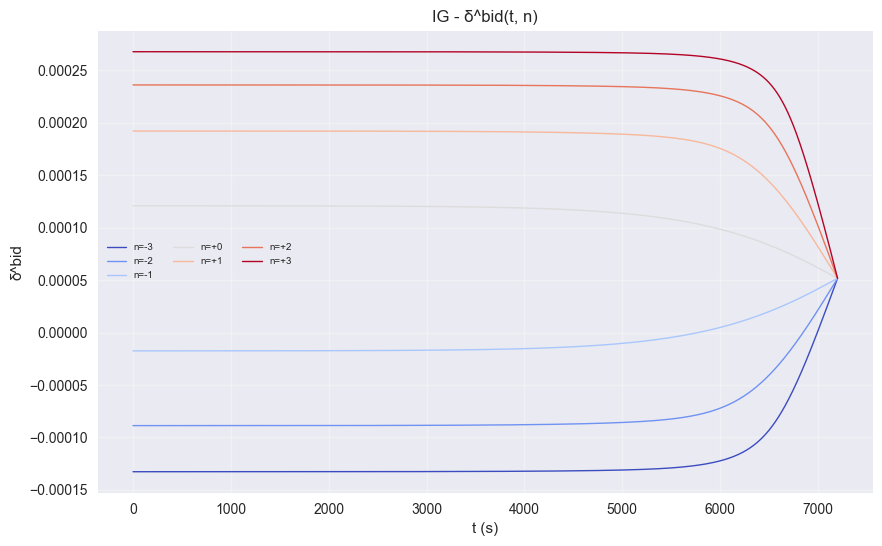

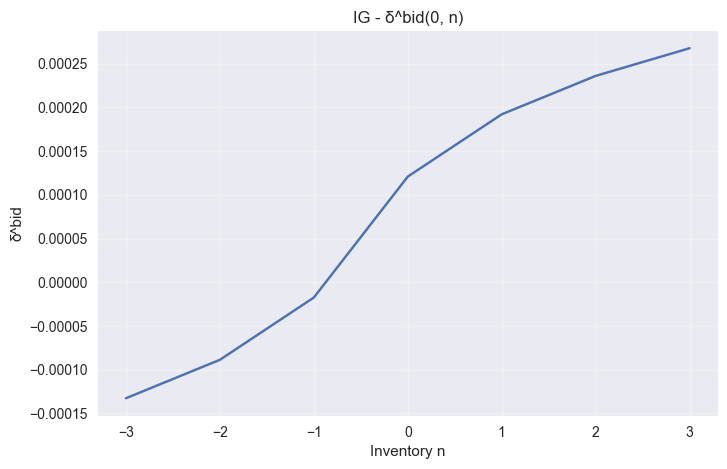

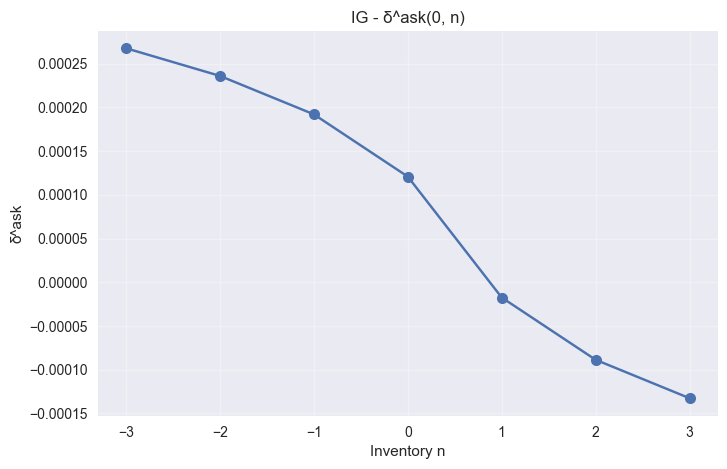

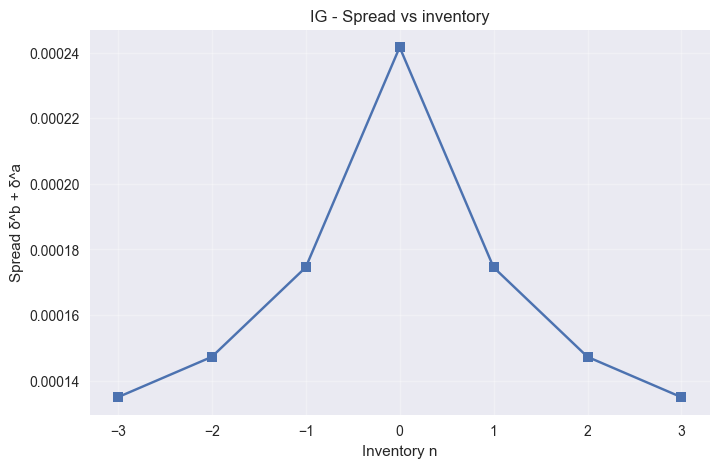

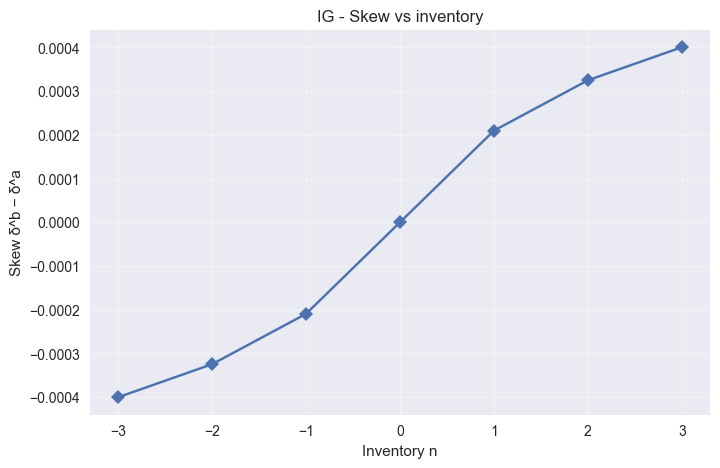

In [7]:
# IG Figures (1–5)
plot_asset(sol_ig, IG, "IG")

This figure reproduces the qualitative behavior of Figure 1 for IG and Figure 10 for HY.
All curves converge rapidly to a nearly stationary level away from the terminal time T, confirming that the asymptotic regime is reached well before the end of the horizon. This is exactly what the paper reports for the IG case, where the asymptotic regime is reached in less than one hour

The optimal bid distance is increasing in inventory. Since the bid price is S−δb, a larger δb means a lower, more conservative bid. Hence, when the market maker is long, he reduces the probability of buying more inventory.

The optimal ask distance is decreasing in inventory. Since the ask price is S+δa, a smaller δa means a more aggressive ask, closer to the mid-price. Hence, when the market maker is long, he increases the probability of selling inventory.

The exact spread is not constant across inventory levels. This matches the paper’s observation that the exact ODE solution departs from the closed-form approximation, which would predict a constant spread under exponential intensities .

The skew is antisymmetric and vanishes at zero inventory, as implied by symmetry. It is increasing in inventory but not perfectly linear, which again matches the paper’s qualitative conclusion for the exact solution.

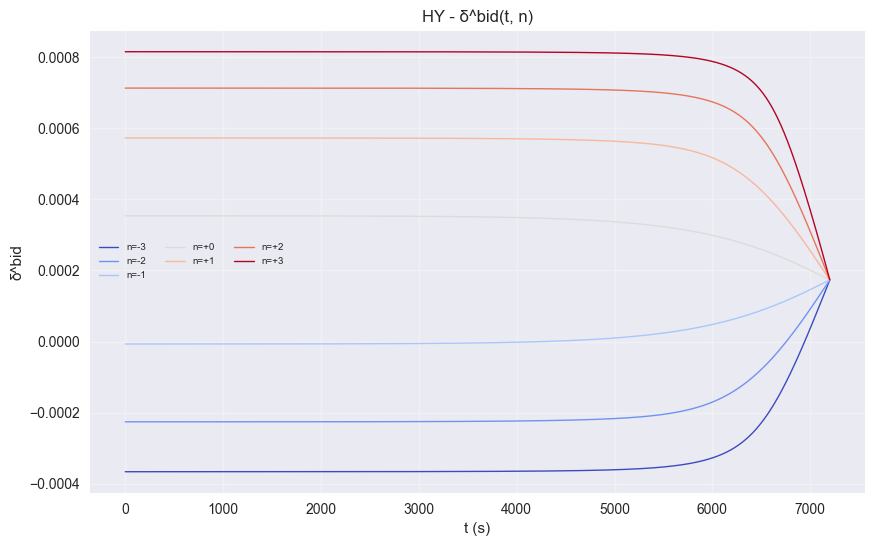

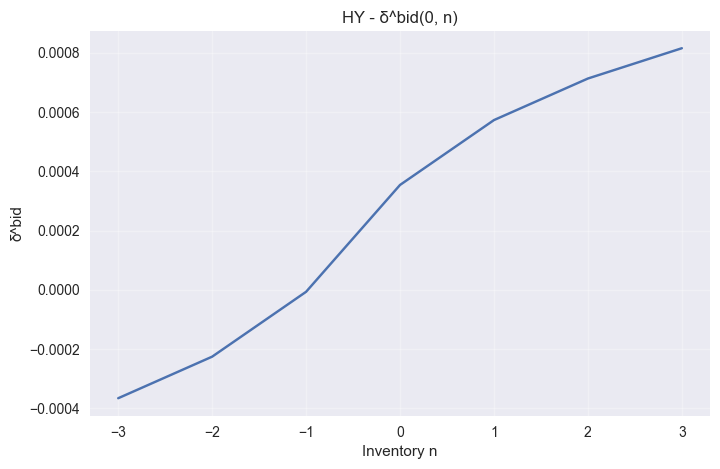

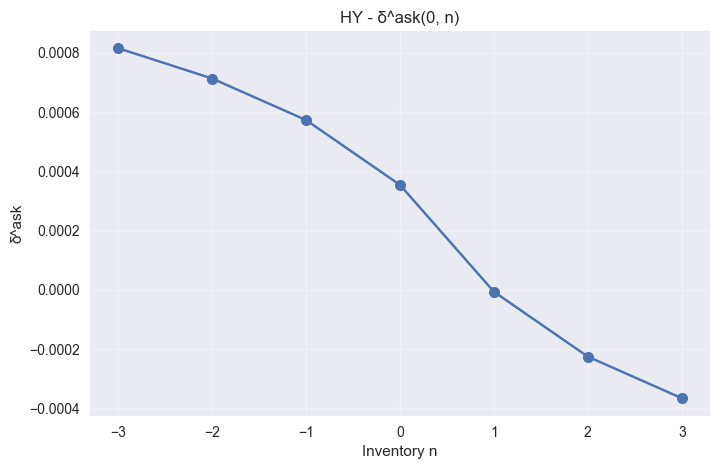

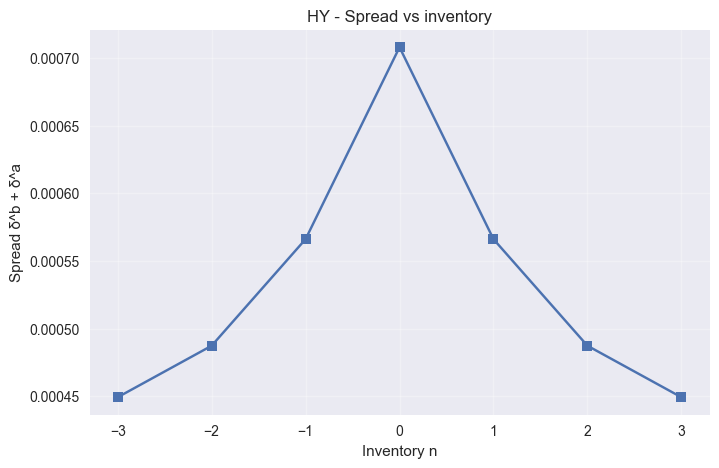

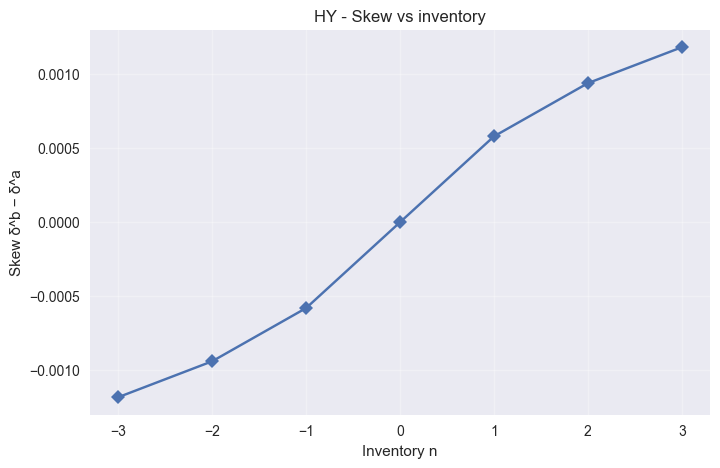

In [8]:
# HY Figures (10–14)
plot_asset(sol_hy, HY, "HY")

Negative quote distances at extreme inventories are not necessarily numerical errors. They indicate that the model recommends quoting through the reference price to unwind inventory very aggressively near the boundaries.

The function $\theta(t, q)$ is the **reduced value function**, it encodes the full optimal strategy.

The ODE (Eq. 3.9) says that $\theta$ must balance:
- **Inventory risk**: $\frac{1}{2}\gamma\sigma^2 q^2$ (quadratic penalty pushing $\theta$ down for large $|n|$)
- **Trading benefit**: $H_\xi(p)$ terms (the expected gain from fills)

Let's inspect $\theta(0, n)$ directly, its shape determines the quotes through the discrete gradient $(\theta_n - \theta_{n\pm 1})/\Delta$.

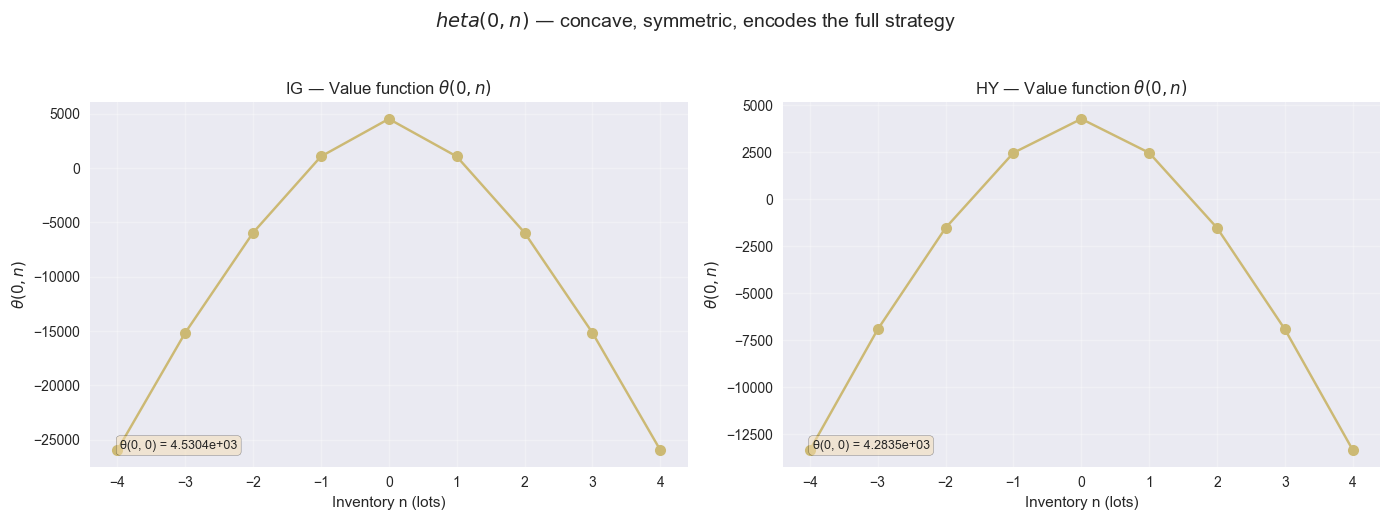

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sol, params, name in [(axes[0], sol_ig, IG, "IG"), (axes[1], sol_hy, HY, "HY")]:
    lots = sol["lots"]
    theta_0 = sol["theta"][0, :]
    
    ax.plot(lots, theta_0, "o-", markersize=8, color="C4")
    ax.set_xlabel("Inventory n (lots)", fontsize=11)
    ax.set_ylabel(r"$\theta(0, n)$", fontsize=11)
    ax.set_title(f"{name} — Value function $\\theta(0, n)$", fontsize=12)
    ax.grid(alpha=0.3)
    
    # Show that it's symmetric and concave
    ax.text(0.05, 0.05, f"θ(0, 0) = {theta_0[int(params['Q'])]:.4e}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

fig.suptitle(r"$	heta(0, n)$ — concave, symmetric, encodes the full strategy",
             fontsize=14, y=1.03)
fig.tight_layout()
plt.show()


The reduced value function θ(0,n) is symmetric and concave in the inventory index. Its discrete gradients determine the bid and ask quotes. The peak at n=0 reflects the fact that holding no inventory is the least risky state.

We observe that:

- Bid quotes increase with inventory
- Ask quotes decrease with inventory
- Spread is not constant
- Skew is not perfectly linear

This confirms nonlinear inventory effects beyond the affine approximation.

**Inventory management**: the optimal market maker skews quotes to mean-revert inventory. This is the dominant effect.

**Non-linearity**: the exact ODE solution reveals that spread and skew are *not* simple functions of inventory, unlike what the closed-form approximation suggests. The deviations are stronger when $\xi\Delta$ is large (IG case: $\xi\Delta = 3000$).

**Asymptotic regime**: the terminal condition becomes irrelevant well before $T$, justifying the use of the $t = 0$ values as the "steady-state" strategy.

In [10]:
def check_single_asset_diagnostics(sol, params, label, tol=1e-10):
    lots = sol["lots"].astype(int)
    theta = sol["theta"]
    db = sol["delta_bid"]
    da = sol["delta_ask"]
    times = sol["times"]
    Q = int(params["Q"])

    print(f"\n=== Diagnostics for {label} ===")

    # 1) Symmetry of theta: theta(t,n) = theta(t,-n)
    theta_sym_err = 0.0
    for j, n in enumerate(lots):
        j_sym = np.where(lots == -n)[0][0]
        theta_sym_err = max(theta_sym_err, np.max(np.abs(theta[:, j] - theta[:, j_sym])))
    print(f"Max symmetry error on theta(t,n)=theta(t,-n): {theta_sym_err:.3e}")

    # 2) Bid/ask symmetry: delta^b(t,n) = delta^a(t,-n)
    quote_sym_err = 0.0
    for j, n in enumerate(lots):
        j_sym = np.where(lots == -n)[0][0]
        db_col = db[:, j]
        da_sym_col = da[:, j_sym]
        mask = np.isfinite(db_col) & np.isfinite(da_sym_col)
        if np.any(mask):
            quote_sym_err = max(quote_sym_err, np.max(np.abs(db_col[mask] - da_sym_col[mask])))
    print(f"Max symmetry error on delta^b(t,n)=delta^a(t,-n): {quote_sym_err:.3e}")

    # 3) Monotonicity of bid at t=0
    db0 = db[0, :]
    mask = np.isfinite(db0)
    db0_finite = db0[mask]
    mono_bid = np.all(np.diff(db0_finite) >= -tol)
    print(f"Bid monotonic increasing in inventory at t=0: {mono_bid}")

    # 4) Monotonicity of ask at t=0
    da0 = da[0, :]
    mask = np.isfinite(da0)
    da0_finite = da0[mask]
    mono_ask = np.all(np.diff(da0_finite) <= tol)
    print(f"Ask monotonic decreasing in inventory at t=0: {mono_ask}")

    # 5) Skew at n=0
    j0 = np.where(lots == 0)[0][0]
    skew0 = db[0, j0] - da[0, j0]
    print(f"Skew at n=0, t=0: {skew0:.3e}")

    # 6) Asymptotic regime: compare t=0 to t=epsilon
    eps_idx = min(len(times) - 1, max(1, len(times)//20))
    asymp_err_bid = np.nanmax(np.abs(db[0, :] - db[eps_idx, :]))
    asymp_err_ask = np.nanmax(np.abs(da[0, :] - da[eps_idx, :]))
    print(f"Asymptotic check |delta_bid(0)-delta_bid(eps)|_max: {asymp_err_bid:.3e}")
    print(f"Asymptotic check |delta_ask(0)-delta_ask(eps)|_max: {asymp_err_ask:.3e}")

In [11]:
check_single_asset_diagnostics(sol_ig, IG, "IG")
check_single_asset_diagnostics(sol_hy, HY, "HY")


=== Diagnostics for IG ===
Max symmetry error on theta(t,n)=theta(t,-n): 1.246e-10
Max symmetry error on delta^b(t,n)=delta^a(t,-n): 3.402e-18
Bid monotonic increasing in inventory at t=0: True
Ask monotonic decreasing in inventory at t=0: True
Skew at n=0, t=0: -1.382e-18
Asymptotic check |delta_bid(0)-delta_bid(eps)|_max: 8.734e-09
Asymptotic check |delta_ask(0)-delta_ask(eps)|_max: 8.734e-09

=== Diagnostics for HY ===
Max symmetry error on theta(t,n)=theta(t,-n): 2.576e-10
Max symmetry error on delta^b(t,n)=delta^a(t,-n): 2.656e-17
Bid monotonic increasing in inventory at t=0: True
Ask monotonic decreasing in inventory at t=0: True
Skew at n=0, t=0: 2.472e-17
Asymptotic check |delta_bid(0)-delta_bid(eps)|_max: 1.923e-08
Asymptotic check |delta_ask(0)-delta_ask(eps)|_max: 1.923e-08
